# Dataset EDA

Quora Question Pairs: https://www.kaggle.com/datasets/quora/question-pairs-dataset

In [2]:
!rm -rf dataset/
!mkdir dataset/
!curl -L -o dataset/question-pairs-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/quora/question-pairs-dataset
!unzip dataset/question-pairs-dataset.zip -d dataset/
!rm dataset/question-pairs-dataset.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 20.7M  100 20.7M    0     0  6398k      0  0:00:03  0:00:03 --:--:-- 9654k
Archive:  dataset/question-pairs-dataset.zip
  inflating: dataset/questions.csv   


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
pd.set_option("display.max_colwidth", None)

In [2]:
df = pd.read_csv("dataset/questions.csv", index_col="id")
df[:10]

,qid1,qid2,question1,question2,is_duplicate
id,,,,,
0,1,2,What is the step by step guide to invest in share market in india?,What is the step by step guide to invest in share market?,0
1,3,4,What is the story of Kohinoor (Koh-i-Noor) Diamond?,What would happen if the Indian government stole the Kohinoor (Koh-i-Noor) diamond back?,0
2,5,6,How can I increase the speed of my internet connection while using a VPN?,How can Internet speed be increased by hacking through DNS?,0
3,7,8,Why am I mentally very lonely? How can I solve it?,"Find the remainder when [math]23^{24}[/math] is divided by 24,23?",0
4,9,10,"Which one dissolve in water quikly sugar, salt, methane and carbon di oxide?",Which fish would survive in salt water?,0
5,11,12,Astrology: I am a Capricorn Sun Cap moon and cap rising...what does that say about me?,"I'm a triple Capricorn (Sun, Moon and ascendant in Capricorn) What does this say about me?",1
6,13,14,Should I buy tiago?,What keeps childern active and far from phone and video games?,0
7,15,16,How can I be a good geologist?,What should I do to be a great geologist?,1
8,17,18,When do you use シ instead of し?,"When do you use ""&"" instead of ""and""?",0


In [28]:
mask = df.apply(
    lambda row: isinstance(row["question1"], str) and isinstance(row["question2"], str),
    axis=1,
)
df_clean = df[mask]
df_clean.info()

<class 'pandas.DataFrame'>
Index: 404348 entries, 0 to 404350
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   qid1          404348 non-null  int64
 1   qid2          404348 non-null  int64
 2   question1     404348 non-null  str  
 3   question2     404348 non-null  str  
 4   is_duplicate  404348 non-null  int64
dtypes: int64(3), str(2)
memory usage: 64.8 MB


In [30]:
df_clean.is_duplicate.value_counts()                

is_duplicate
0    255042
1    149306
Name: count, dtype: int64

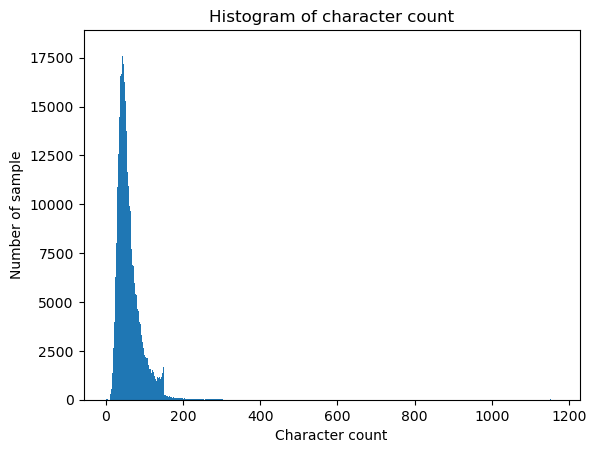

In [55]:
len1 = df_clean.question1.apply(lambda text: len(text)).to_list()
len2 = df_clean.question2.apply(lambda text: len(text)).to_list()
plt.hist(len1 + len2, bins="auto")
plt.title("Histogram of character count")
plt.xlabel("Character count")
plt.ylabel("Number of sample")
plt.show()

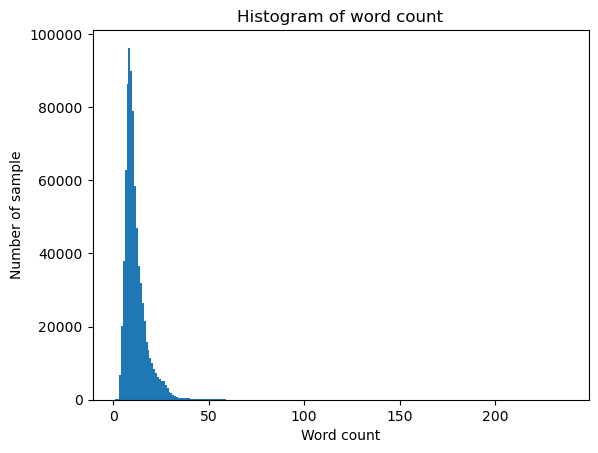

In [56]:
len1 = df_clean.question1.apply(lambda text: len(text.split())).to_list()
len2 = df_clean.question2.apply(lambda text: len(text.split())).to_list()
plt.hist(len1 + len2, bins="auto")
plt.title("Histogram of word count")
plt.xlabel("Word count")
plt.ylabel("Number of sample")
plt.show()

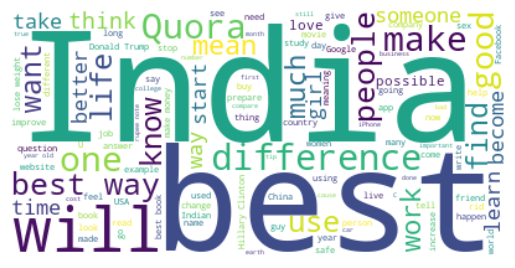

In [63]:
cloud = WordCloud(background_color="white").generate(
    " ".join(df_clean.question1) + " ".join(df_clean.question2)
)

plt.figure()
plt.imshow(cloud, interpolation="bilinear")
plt.axis("off")
plt.show()